# 4. Apply ysoisochrone to a large dataset

In [1]:
import numpy as np
import pandas as pd

import os, sys, tqdm, copy

import tqdm
import tqdm.notebook

import matplotlib.pyplot as plt
import matplotlib

style = [
    # 'seaborn-ticks',
    {
        'figure.dpi': 300,
        'font.size': 12,
        'image.cmap': 'inferno',
        'font.family': 'serif',
        'font.serif': ['Times', 'Times New Roman'] + plt.rcParams['font.serif'],
        'xtick.top': True,
        'xtick.direction': 'in',
        'ytick.right': True,
        'ytick.direction': 'in',
        'mathtext.fontset': 'cm'
        }]
plt.style.use(style)

import scipy.io

In [2]:
# github_dir = '/Users/dingshandeng/github/ysoisochrone/'

# # os.chdir(os.path.join(github_dir, 'tests'))
# sys.path.append(os.path.join(github_dir))

# import ysoisochrone.utils as utils
# import ysoisochrone.bayesian as bayesian
# import ysoisochrone.plotting as plotting
import ysoisochrone

In [4]:
df_prop = pd.read_csv('/Users/dingshandeng/github/ysoisochrone/tutorial_notebooks/example_targets.csv', skiprows=6)

# For test targets from Lupus
toobright = [] # ['0']  
toofaint = [] # ['0']
median_age = 1.0 # Myrs	

err_Teff = ysoisochrone.utils.assign_unc_teff(df_prop['Teff[K]'].values)
err_Lumi = ysoisochrone.utils.assign_unc_lumi(df_prop['Luminosity[Lsun]'].values)
df_prop['e_Teff[K]'] = err_Teff
df_prop['e_Luminosity[Lsun]'] = err_Lumi

# you need to specify the source names
toobright = ['J11065906-7718535','J11094260-7725578',
   		     'J11105597-7645325','J11183572-7935548']
toofaint = ['J10533978-7712338','J11063945-7736052','J11082570-7716396',
            'J11111083-7641574','J11160287-7624533']

# the median age for Cham I star-forming region
median_age = 6.48 # Myrs, the age took from Pasucci+2016 choice

# form the df_toobright and df_toofaint only for plot
idx_toobright = []
idx_toofaint  = []
for idx_t in df_prop.index:
    if df_prop.loc[idx_t, 'Source'] in toobright:
        idx_toobright.append(idx_t)
    if df_prop.loc[idx_t, 'Source'] in toofaint:
        idx_toofaint.append(idx_t)

df_toobright = df_prop.loc[idx_toobright]
df_toofaint = df_prop.loc[idx_toofaint]

In [5]:
# ysoisochrone.plotting.simple_plot_hr_diagram_feiden_n_baraffe(df_prop)

## Plot to show the tracks

Please check the most updated model section to see what are the available models. Here are some examples

'Baraffe2015', 'Feiden2016', 'Feiden2016_magnetic', 'parsec_v1p2', 'parsec_v2p0', 'mist_v1p2', 'siess2000', 'spots0000', 'spots0169', 'spots0339', 'spots0508', 'spots0847', 'pisa'

using the built in isochrones
-----------------------
0.10 Msun is skipped because it is smaller than the grid min mass of 0.20 Msun
0.20 Msun is skipped because it is smaller than the grid min mass of 0.20 Msun


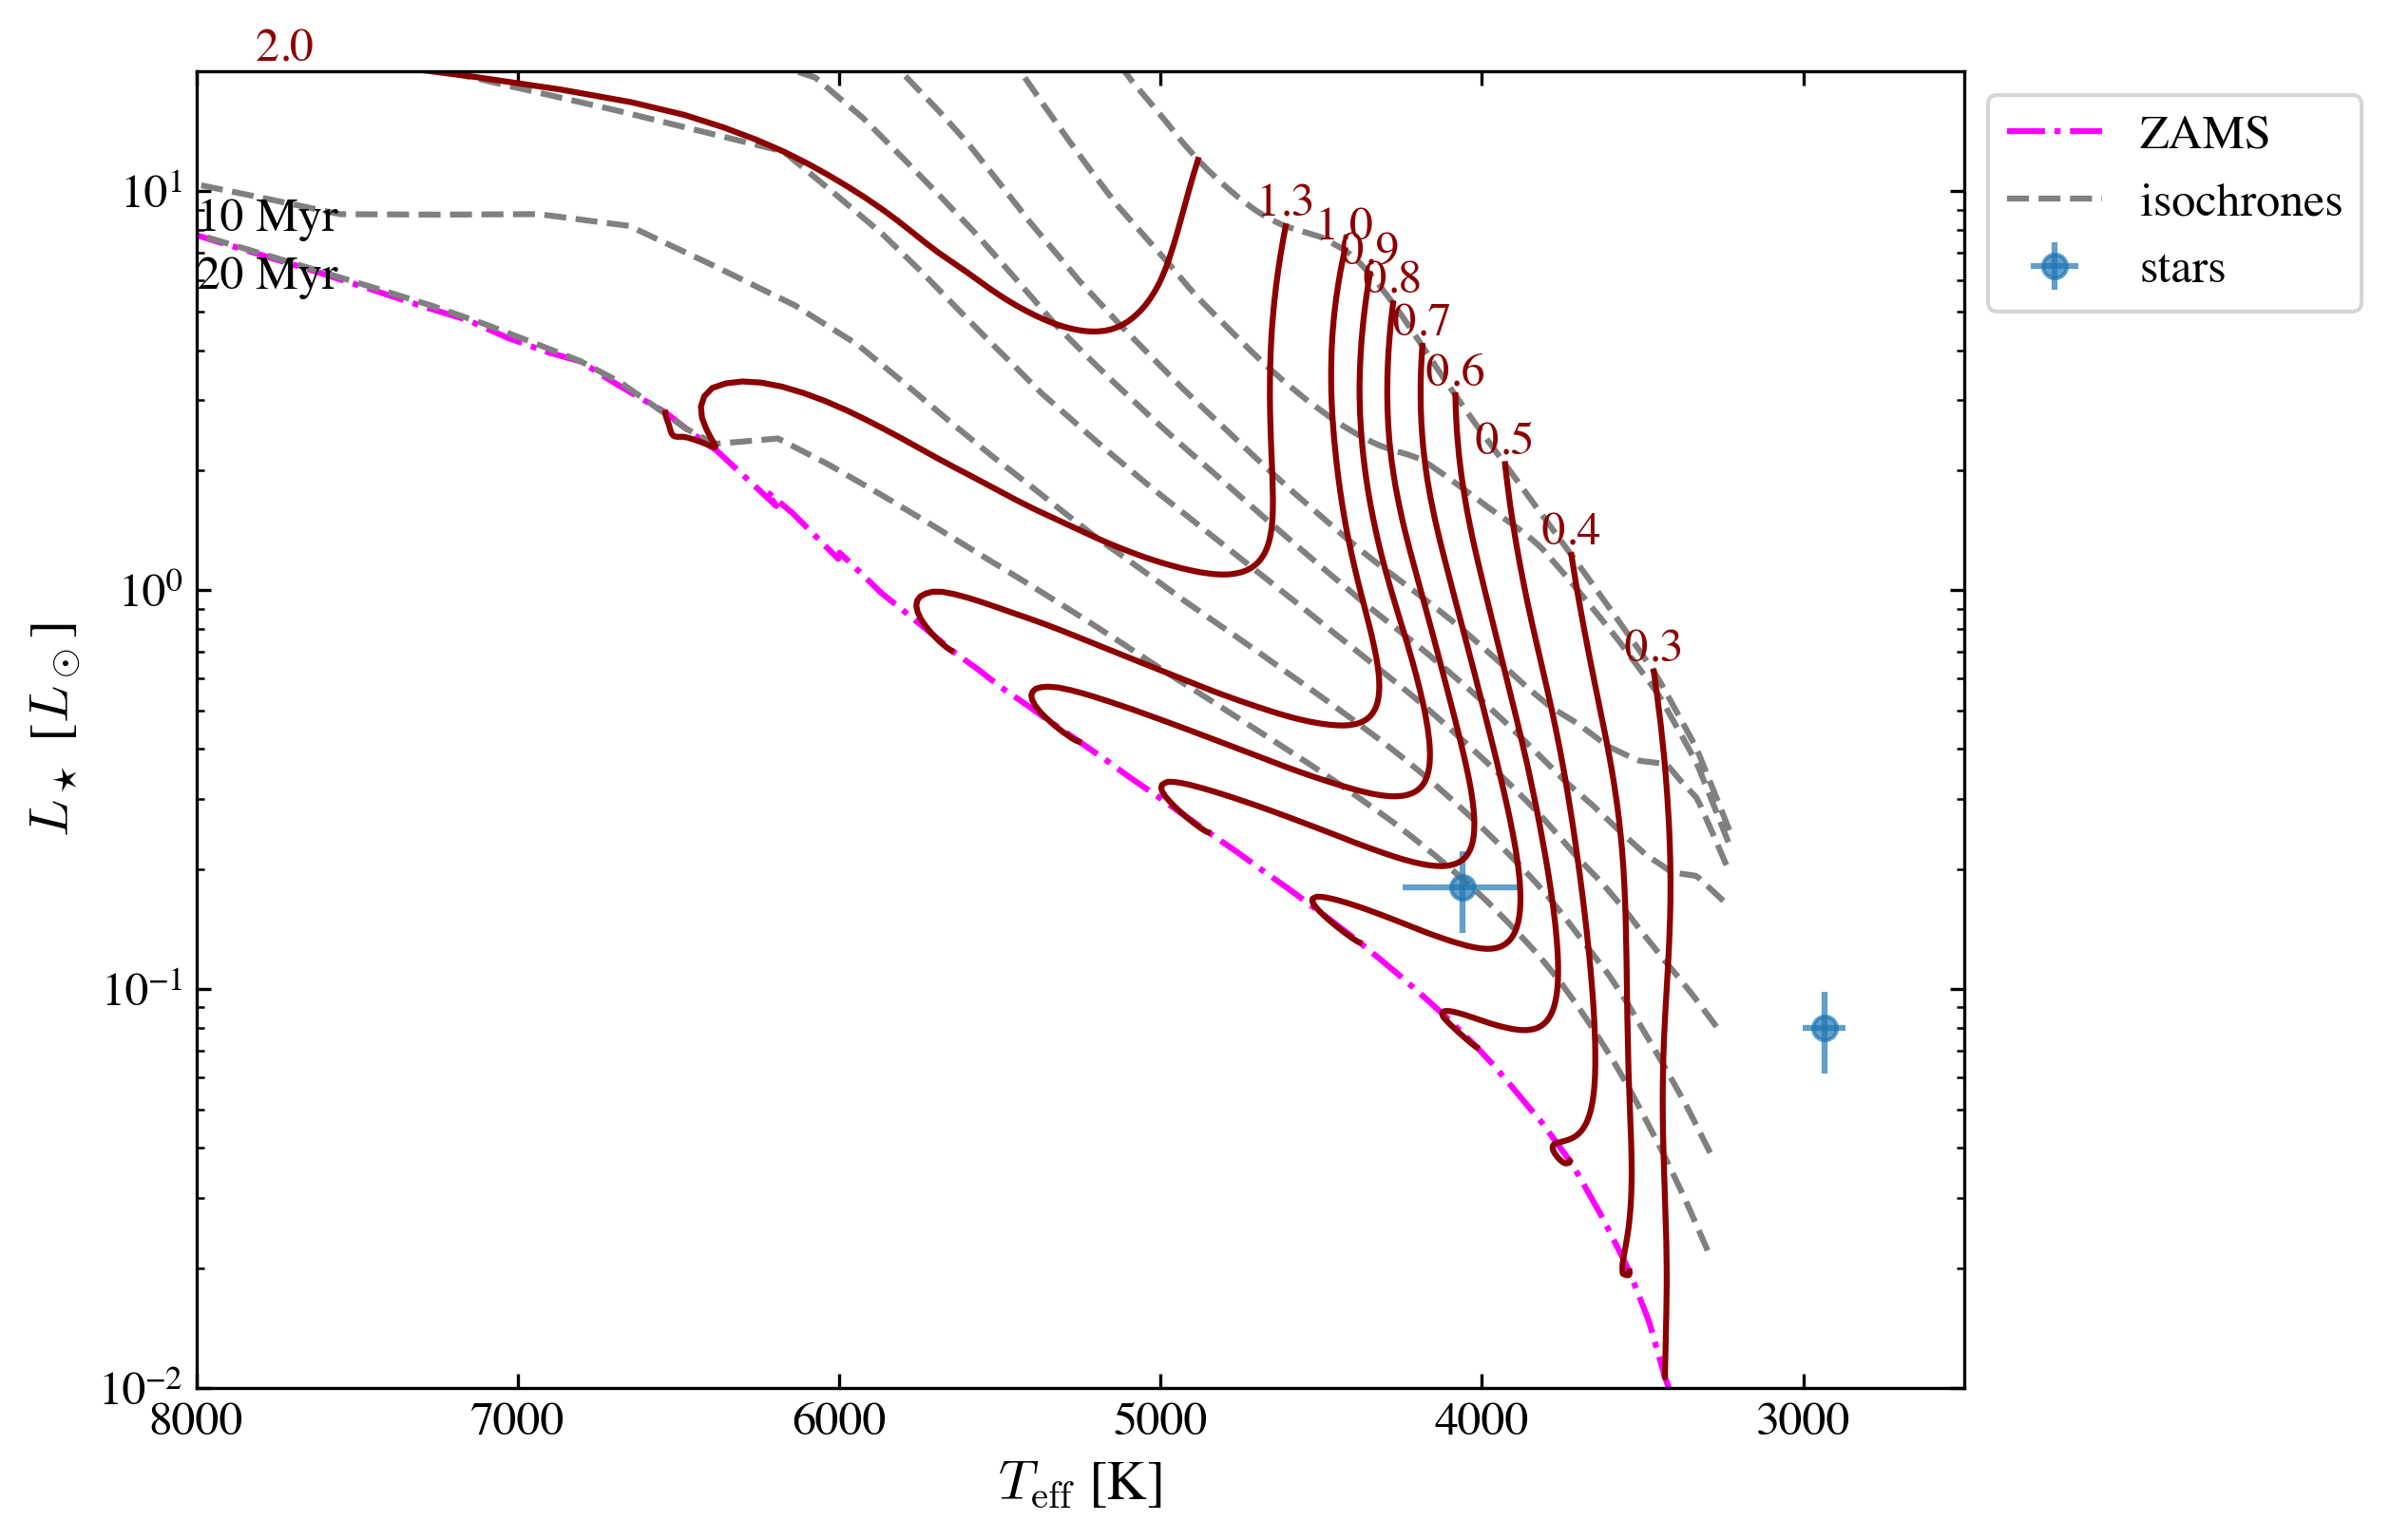

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

isochrone = ysoisochrone.isochrone.Isochrone()
# mat_file_dir = './isochrones_data/Baraffe_AgeMassGrid_YSO_up100Myrs_matrix.mat'

# isochrone.set_tracks('customize', load_file=mat_file_dir)

# isochrone.set_tracks('Feiden2016_magnetic')

isochrone.set_tracks('pisa') # "PISA"

ysoisochrone.plotting.plot_hr_diagram(isochrone, df_prop[1:3], ax_set=ax, 
                                      ages_to_plot=[0.5e6, 1.0e6, 2.0e6, 3.0e6, 5.0e6, 10.0e6, 20.0e6], 
                                      masses_to_plot=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.3, 2.0],
                                      xlim_set=[8000, 2500], ylim_set=[0.01, 20.0])


# ax.set_xlim(7000, 5000)
# ax.set_ylim(0.5, 10) # , 50.0)
# ax.set_xscale("log")
# ax.set_xlabel()

plt.show()

## Go through the whole table using the force_through option

In the original code, we need to manually mark the targets that are too bright or too faint, and if any target is falling outside of the track, the code raises a value error and stops there. 

```python
  Normal behavior (force_through=False, default):
  Raises a ValueError:
  "The mass is the largest in the grid. This needs to be sorted out!
  Consider extending the isochrone grid or removing this target from the list."
```

During mass estimation, the code marginalizes the 2D posterior to derive the best-fit mass. If the peak of the mass likelihood falls at the upper edge of the isochrone grid, this means the model grid doesn't extend far enough to constrain the star's mass from above -- so that this target's mass/age cannot be inferred correctly from the evolutionary tracks.

This is a safe choice but could be annoying if it is applied to a large dataset.

### The new option: force_through

[!Important] Using `force_through` could be **DANGEROUS**, so please make sure to double-check the results that are flagged after the code.

`force_through` is a safety bypass flag — that controls how the function handles a specific failure case during Bayesian mass estimation.

with

```python
force_through=True
```

Instead of raising an error, it:

1. Proceeds — continues with plotting and result collection without stopping
2. Clamps the upper mass uncertainty to the grid maximum (mass_unc[1] = log_masses_dummy[-1]), effectively saying "the upper bound is at least as large as the
grid edge"
1. Emits a warning (if verbose=True) that the upper bound is artificially set and results are biased

### Why it's dangerous

The upper mass uncertainty is no longer physically meaningful — it's just a grid boundary. The returned mass estimate is a lower bound on the true mass.
Results should not be interpreted as reliable for scientific use.

### Intended use

Testing and debugging only — for example, when experimenting with a new grid (like model='pisa' in the experimental notebooks) to check that the pipeline runs end-to-end before extending the grid to cover all targets properly.

The targets that have issues will also be flagged (stored in the `flag_all`). 

The possible flag values are explained below.

  0%|          | 0/2 [00:00<?, ?it/s]

using the built in isochrones
-----------------------


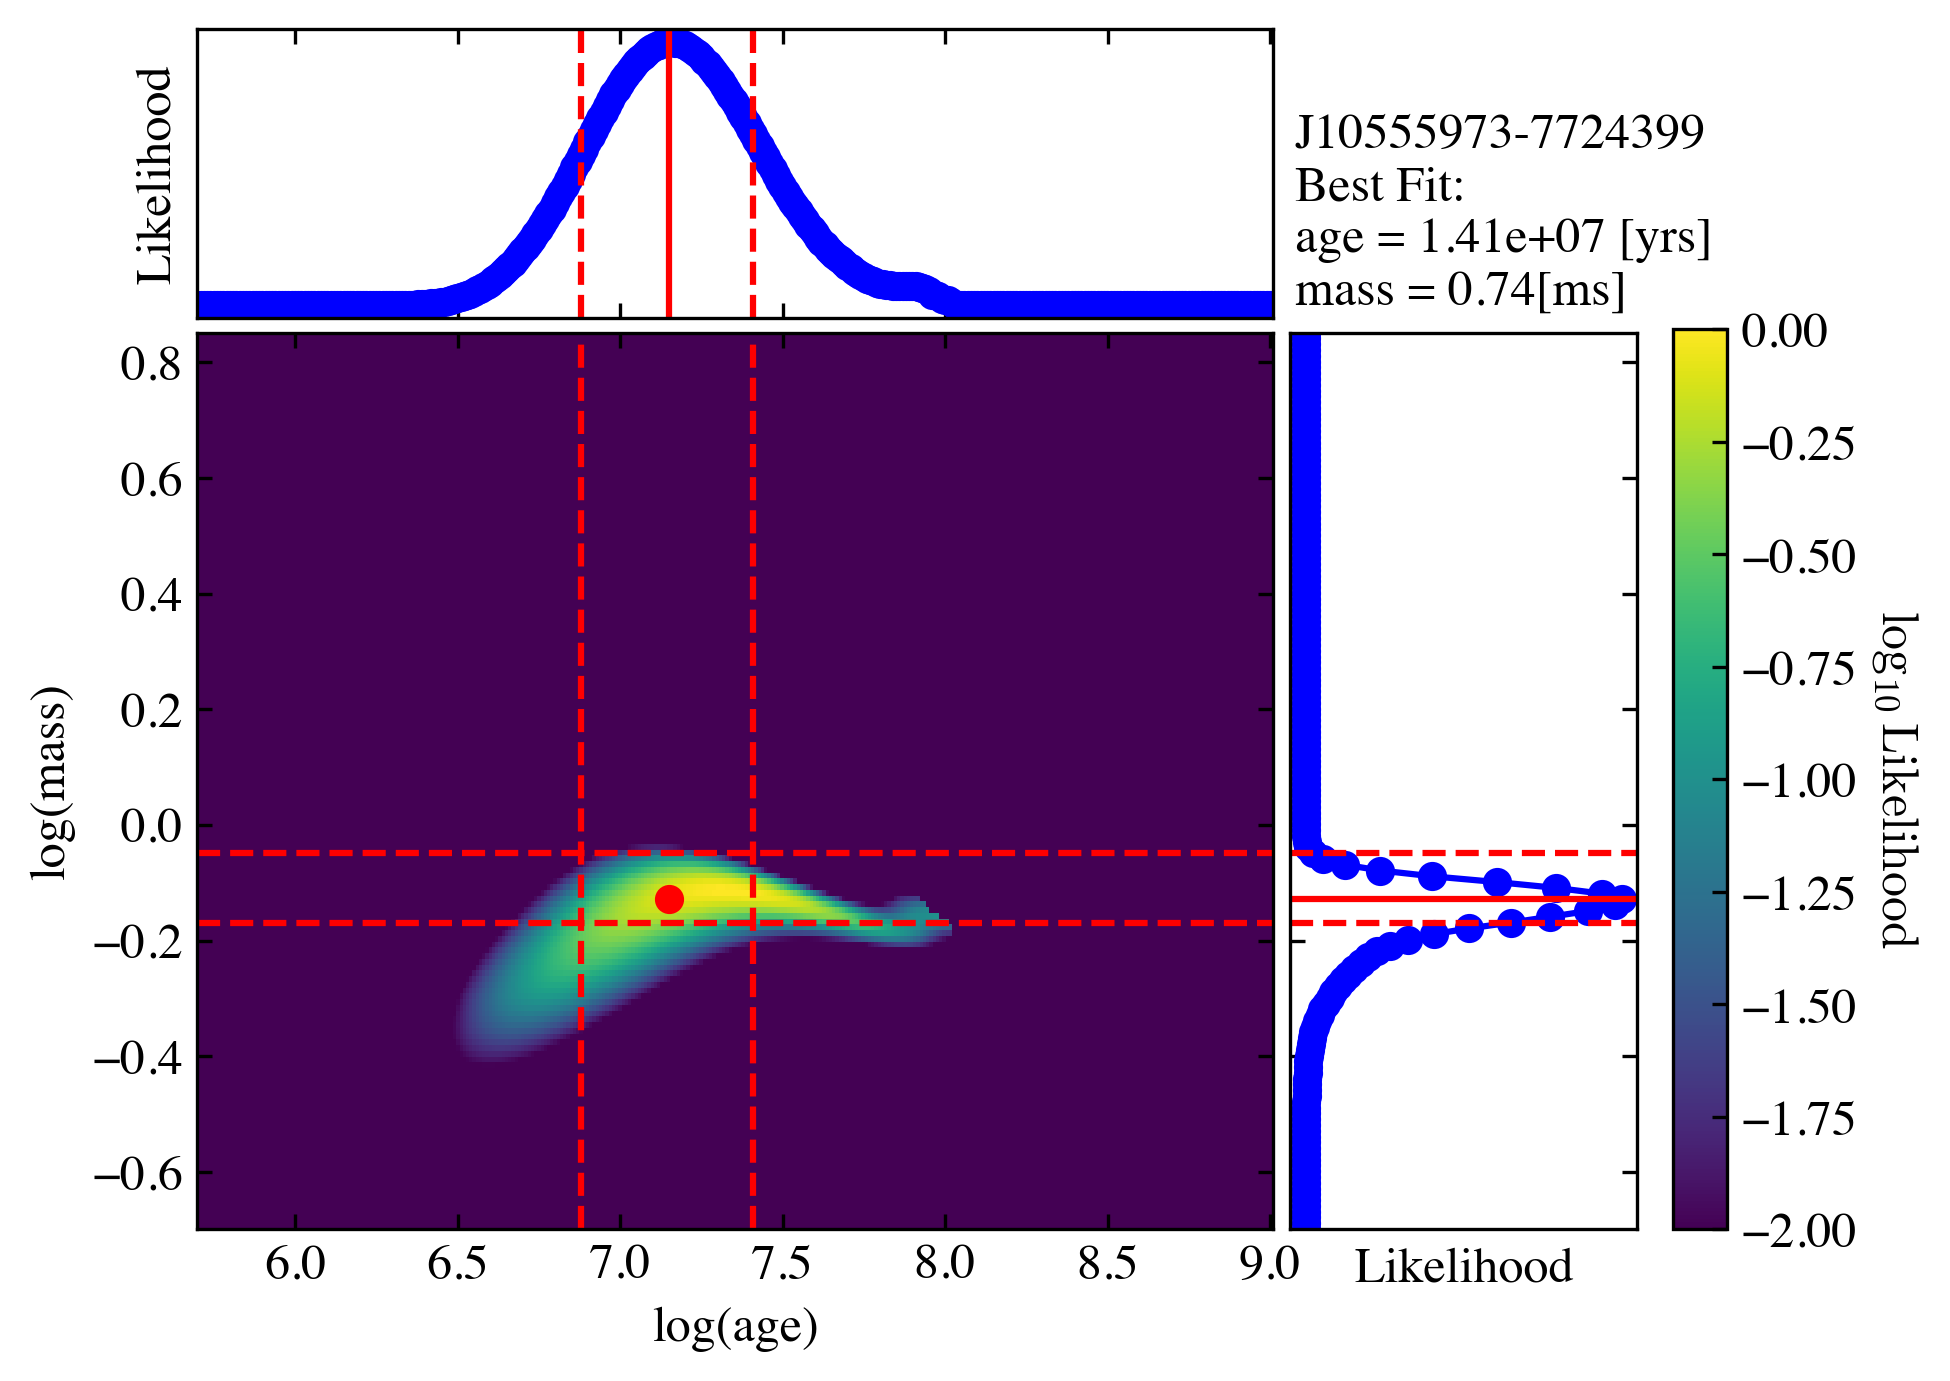

100%|██████████| 2/2 [00:00<00:00,  4.75it/s]

using the built in isochrones
-----------------------


In [7]:
best_logmass_output, best_logage_output, lmass_all, lage_all, flag_all =\
    ysoisochrone.bayesian.derive_stellar_mass_age(df_prop[1:3], model='pisa', plot=True, toobright=toobright, toofaint=toofaint, median_age=median_age, force_through=True)

In [8]:
print("logmass\n", best_logmass_output)
print("logage\n", best_logage_output)
print("flags\n", flag_all)

logmass
 [[-0.12897 -0.16897 -0.04897]
 [     nan      nan      nan]]
logage
 [[7.14897 6.87897 7.40897]
 [    nan     nan     nan]]
flags
 ['good', 'out_of_grid_T']


### Possible flag values

`flag_all` is a list of strings (one per target star in df_prop). Flags are mutually exclusive per target.

`good`
: Set when: Successful Bayesian estimation within the model grid
: Output: Valid values with uncertainties

`toobright`
: Set when: Source name is in the toobright list
: Output: Mass via 1D Bayesian at youngest grid age; age = min(log_age); no age uncertainty

`toofaint`
: Set when: Source name is in the toofaint list
: Output: Mass via 1D Bayesian at median_age; age = median_age; no age uncertainty

`out_of_grid_T`
: Set when: Target’s logTeff falls outside the model grid range
: Output: All NaN

`out_of_grid_L`
: Set when: Target’s logL falls outside the model grid range
: Output: All NaN

`out_of_grid_TL`
: Set when: Both logTeff and logL are outside the model grid
: Output: All NaN
